In [9]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

tf.config.run_functions_eagerly(True)

In [10]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
NUM_CLASSES = 5
EPOCHS = 20

train_dir = r"train2"
test_dir  = r"test2"

In [11]:
# 1) Генератори даних (аугментація + нормалізація)
# У статті згадується горизонтальне дзеркалення і аугментація для міноритарних класів.
# Тут задаємо типову аугментацію + horizontal_flip=True.
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    horizontal_flip=True,
    rotation_range=30,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10
)

# Для тесту/валідації зазвичай тільки нормалізація
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",          # 48x48 grey-scale
    batch_size=BATCH_SIZE,
    class_mode="categorical",        # categorical_crossentropy
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 20170 images belonging to 5 classes.
Found 5813 images belonging to 5 classes.


In [12]:
# 2) CNN архітектура: 4 Conv шари + 2 Dense (за описом)
model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    # Conv block 1
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 2
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 3
    layers.Conv2D(512, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv block 4
    layers.Conv2D(512, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten + 2 fully connected (Dense) layers
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    # Output: Dense + Softmax (7 класів)
    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [13]:
# 3) Компіляція: Adam + categorical_crossentropy + accuracy (як в статті)
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 12, 12, 512)         │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,346,629 (16.58 MB)

 Trainable params: 4,342,661 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [14]:
# --- Колбеки ---
early_stop = EarlyStopping(
    monitor='val_loss',      # спостереження за валідаційною втратою
    patience=4,              # кількість епох без покращення перед зупинкою
    restore_best_weights=True # відновити найкращі ваги
)

checkpoint = ModelCheckpoint(
    filepath='5classes_best_model.h5',     # шлях збереження моделі
    monitor='val_accuracy',       # метрика для збереження
    save_best_only=True,
    verbose=1
)

In [15]:
# 4) Навчання: 15 епох (як в статті)
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.2442 - loss: 1.8500
Epoch 1: val_accuracy improved from -inf to 0.29985, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 279s 881ms/step - accuracy: 0.2443 - loss: 1.8498 - val_accuracy: 0.2998 - val_loss: 1.6540
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.2701 - loss: 1.6922
Epoch 2: val_accuracy improved from 0.29985 to 0.30088, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 277s 878ms/step - accuracy: 0.2701 - loss: 1.6921 - val_accuracy: 0.3009 - val_loss: 1.6117
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.2908 - loss: 1.6483
Epoch 3: val_accuracy improved from 0.30088 to 0.32840, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 277s 878ms/step - accuracy: 0.2908 - loss: 1.6482 - val_accuracy: 0.3284 - val_loss: 1.5417
Epoch 4/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.3014 - loss: 1.6077
Epoch 4: val_accuracy improved from 0.32840 to 0.35249, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 277s 878ms/step - accuracy: 0.3014 - loss: 1.6077 - val_accuracy: 0.3525 - val_loss: 1.5311
Epoch 5/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.3197 - loss: 1.5693
Epoch 5: val_accuracy improved from 0.35249 to 0.38311, saving model to 5classes_best_model.h5


...

316/316 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.4774 - loss: 1.2705 - val_accuracy: 0.5314 - val_loss: 1.2076
Epoch 14/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.4853 - loss: 1.2447
Epoch 14: val_accuracy improved from 0.53140 to 0.55944, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.4853 - loss: 1.2446 - val_accuracy: 0.5594 - val_loss: 1.1094
Epoch 15/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.4988 - loss: 1.2217
Epoch 15: val_accuracy did not improve from 0.55944
316/316 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.4988 - loss: 1.2216 - val_accuracy: 0.5491 - val_loss: 1.1636
Epoch 16/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.5067 - loss: 1.1884
Epoch 16: val_accuracy improved from 0.55944 to 0.57543, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.5067 - loss: 1.1884 - val_accuracy: 0.5754 - val_loss: 1.0821
Epoch 17/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.5134 - loss: 1.1849
Epoch 17: val_accuracy improved from 0.57543 to 0.58920, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.5134 - loss: 1.1848 - val_accuracy: 0.5892 - val_loss: 1.0375
Epoch 18/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.5286 - loss: 1.1644
Epoch 18: val_accuracy did not improve from 0.58920
316/316 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.5286 - loss: 1.1643 - val_accuracy: 0.5847 - val_loss: 1.0593
Epoch 19/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.5396 - loss: 1.1311
Epoch 19: val_accuracy did not improve from 0.58920
316/316 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.5396 - loss: 1.1310 - val_accuracy: 0.5801 - val_loss: 1.0657
Epoch 20/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.5351 - loss: 1.1410
Epoch 20: val_accuracy improved from 0.58920 to 0.60210, saving model to 5classes_best_model.h5


316/316 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.5351 - loss: 1.1409 - val_accuracy: 0.6021 - val_loss: 1.0409


In [16]:
# 5) Оцінювання
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Test accuracy: 0.5892


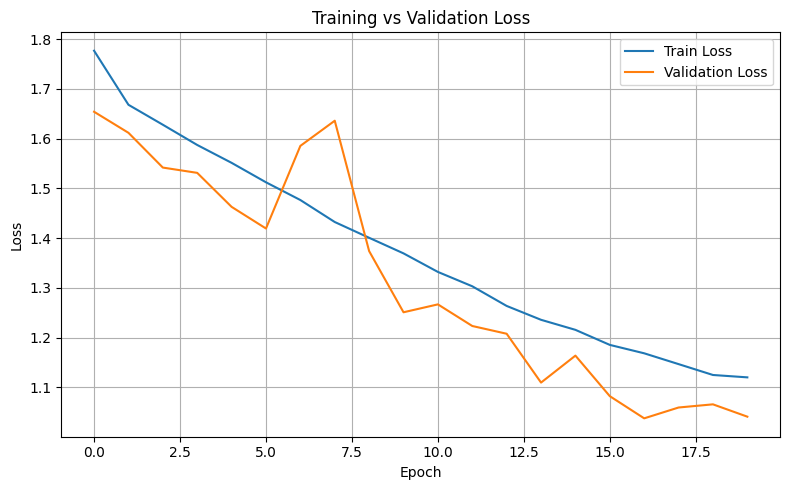

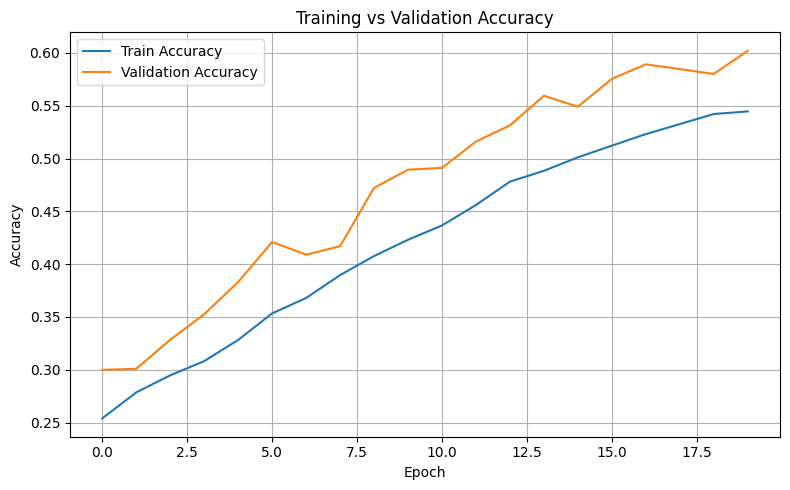

In [17]:
# --- LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- ACCURACY ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step
Test Accuracy: 0.5892
Class Names: ['angry', 'happy', 'neutral', 'sad', 'surprise']


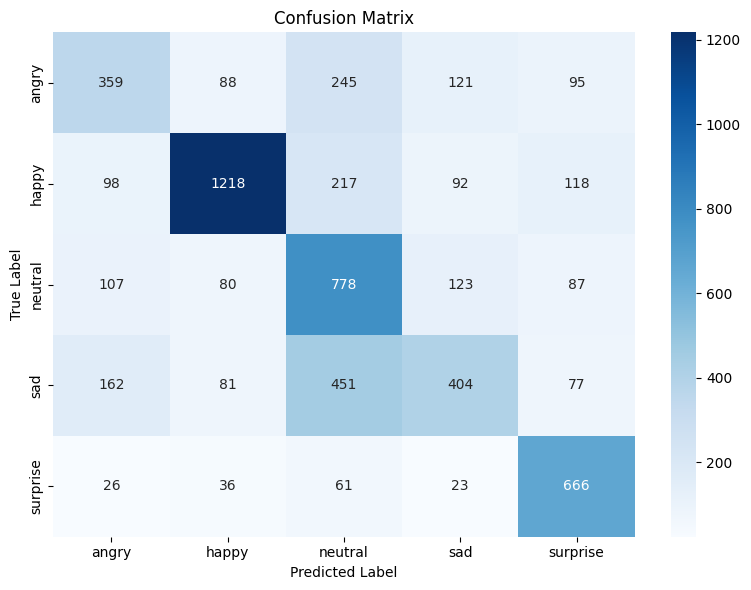

Classification Report:

              precision    recall  f1-score   support

       angry     0.4774    0.3954    0.4325       908
       happy     0.8104    0.6988    0.7505      1743
     neutral     0.4441    0.6621    0.5316      1175
         sad     0.5295    0.3438    0.4169      1175
    surprise     0.6385    0.8202    0.7181       812

    accuracy                         0.5892      5813
   macro avg     0.5800    0.5841    0.5699      5813
weighted avg     0.6035    0.5892    0.5846      5813



In [18]:
# --- ПЕРЕДБАЧЕННЯ ---
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

# --- ТОЧНІСТЬ ---
val_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {val_accuracy:.4f}")

# --- КЛАСИ ---
class_indices = test_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("Class Names:", class_names)

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)